---

## Descripción del proceso ETL y decisiones clave

El proceso ETL se trabajó sobre los datos del Sensor D, el único dispositivo con dos periodos de medición consecutivos en la misma ubicación (P1: 6–11 Nov y P2: 13–25 Nov 2025). El dataset inicial contaba con 13,758 registros y 14 columnas sin valores nulos en las variables ambientales, lo que simplificó la etapa de limpieza.

**Eliminación de variables.** Se descartó `Bat_pct` por ser un indicador operacional del dispositivo, no del entorno. Incluirla podría generar correlaciones espurias con el AQI en momentos en que la batería baja coincidiera con cambios ambientales reales. La columna `sensor_periodo` se transformó a variable binaria (0=P1, 1=P2) para conservar la información de periodo sin meter texto al modelo.

**Manejo de outliers.** Se eligió winsorización al percentil 1–99 sobre otras alternativas (eliminación de filas o criterio 3σ) por dos razones: primero, no reduce el tamaño del dataset y preserva los eventos reales de contaminación dentro del rango válido; segundo, el criterio 3σ asume normalidad y la mayoría de los contaminantes tienen sesgos positivos muy altos (entre 2 y 25), lo que lo invalida. Para `temp_C` se añadió un límite físico de 45°C como techo, ya que las 486 lecturas por encima de ese valor (3.5% de los datos) corresponden a errores del sensor por radiación solar directa sobre el dispositivo, no temperaturas ambientales reales.

**Transformación logarítmica.** Los contaminantes atmosféricos siguen distribuciones log-normales porque su concentración resulta de procesos multiplicativos de dispersión y dilución en la atmósfera. La transformación `log(1+x)` reduce el sesgo de distribuciones como CO (sesgo original: 5.3 → 0.8 tras la transformación) y mejora la separabilidad de clases para modelos lineales. Se aplicó a las 8 variables con sesgo mayor a 1.5; temperatura y humedad quedaron sin transformar por tener distribuciones más simétricas.

**Ingeniería de características temporales.** El EDA mostró patrones diurnos claros en CO₂, CO y temperatura. Para incorporarlos sin introducir la discontinuidad entre las horas 23 y 0, se usó codificación cíclica seno/coseno tanto para la hora del día como para el día de la semana. También se generó una variable binaria de fin de semana, que captura el menor flujo vehicular en esos días.

**Partición del dataset.** Se usó una división cronológica estricta 70/15/15 (train/validation/test) en lugar de una aleatoria. Con datos de serie de tiempo, una partición aleatoria permite que el modelo aprenda del futuro para predecir el pasado, lo que produce métricas artificialmente optimistas. La partición cronológica replica el escenario real de uso.

**Brecha de datos.** La ausencia de registros durante ~50 horas (19–20 noviembre) se documentó con un flag `near_gap` en los registros adyacentes (±2 horas), sin eliminarlos. Esta decisión preserva el tamaño del dataset y le da al modelador la información necesaria para excluirlos si utiliza features de ventana temporal o lags, donde esa transición ficticia podría afectar el aprendizaje.

**Validación con Ingeniería Química.** Las decisiones de preprocesamiento son consistentes con los principios fisicoquímicos de los contaminantes: la transformación log en gases es coherente con los modelos gaussianos de dispersión atmosférica; el límite de 45°C para temperatura corresponde al rango de operación de sensores electroquímicos en condiciones tropicales; la baja correlación de SO₂ con el AQI (r ≈ 0.01) refleja que en zonas urbanas sin fuentes industriales cercanas, el SO₂ en concentraciones de ppb no domina el índice compuesto, lo cual es consistente con la literatura de calidad del aire urbana.

# ETL — Preparación de datos: Calidad del Aire

Este notebook cubre la Fase 3 del proyecto: limpiar y transformar los datos del Sensor D para que queden listos para modelado.

El sensor mide CO₂, TVOC, CO, SO₂, O₃, NO₂, PM2.5, PM10, temperatura y humedad en intervalos de ~1 minuto. La variable que queremos predecir es el **AQI** (escala 1–5).

Flujo general:
- **Extracción** → cargar Excel, quedarnos con Sensor D
- **Transformación** → quitar variables inútiles, tratar outliers, transformar distribuciones, crear features
- **Carga** → exportar CSVs listos para entrenar

## Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})

---
## 1. Extracción

In [4]:
df_raw = pd.read_excel('Data/Datos_maestro_sensores.xlsx')
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])

print(f'Dataset maestro: {df_raw.shape[0]:,} registros × {df_raw.shape[1]} columnas')
print(df_raw['sensor_periodo'].value_counts().to_string())

Dataset maestro: 28,654 registros × 14 columnas
sensor_periodo
E_P2    8343
D_P2    7550
C_P2    6553
D_P1    6208


### Filtrar Sensor D

Nos quedamos con el Sensor D porque es el único con dos periodos en la misma ubicación. Mezclar sensores distintos metería ruido por diferencias de localización que no tienen que ver con la calidad del aire. También tiene el mayor volumen de datos (13,758 registros) vs. los otros que solo tienen un periodo.

In [5]:
df = df_raw[df_raw['sensor_periodo'].str.startswith('D')].copy()
df = df.sort_values('datetime').reset_index(drop=True)

for sp in ['D_P1', 'D_P2']:
    sub = df[df['sensor_periodo'] == sp]
    print(f'{sp}: {sub["datetime"].min()} → {sub["datetime"].max()}  ({len(sub):,} registros)')

print(f'\nTotal: {len(df):,} registros')

D_P1: 2025-11-06 20:09:35 → 2025-11-11 05:59:35  (6,208 registros)
D_P2: 2025-11-13 20:43:03 → 2025-11-25 13:24:23  (7,550 registros)

Total: 13,758 registros


---
## 2. Transformación

### 2.1 Quitar columnas que no sirven

`Bat_pct` mide el nivel de batería del dispositivo. No dice nada del aire, así que sale. Si la dejamos, el modelo podría aprender correlaciones falsas entre batería baja y calidad del aire (que solo existirían si el sensor falla cuando la batería baja, no porque el aire cambie).

`sensor_periodo` la convertimos a binario (0=P1, 1=P2) para capturar si hay diferencias sistemáticas entre semanas.

In [6]:
df['periodo'] = df['sensor_periodo'].map({'D_P1': 0, 'D_P2': 1})
df = df.drop(columns=['sensor_periodo', 'Bat_pct'])

VARS_CONTAM = ['CO2_ppm','TVOC_ppb','CO_ppm','SO2_ppm','O3_ppm','NO2_ppm','PM2_5_ugm3','PM10_ugm3']
VARS_METEO  = ['temp_C','hum_pct']
VARS_AMB    = VARS_CONTAM + VARS_METEO
TARGET      = 'AQI'

print('Columnas actuales:', list(df.columns))

Columnas actuales: ['datetime', 'CO2_ppm', 'TVOC_ppb', 'AQI', 'CO_ppm', 'SO2_ppm', 'O3_ppm', 'NO2_ppm', 'PM2_5_ugm3', 'PM10_ugm3', 'temp_C', 'hum_pct', 'periodo']


### 2.2 Valores nulos

El EDA previo no encontró nulos, pero se verifica formalmente. Si hubiera, usaríamos interpolación temporal lineal (los datos son serie de tiempo con alta autocorrelación, así que interpolar entre vecinos tiene más sentido que usar la media global).

In [7]:
nulos = df[VARS_AMB + [TARGET]].isnull().sum()
print('Nulos por variable:')
print(nulos)

if nulos.sum() == 0:
    print('\nSin nulos — no se requiere imputación.')
else:
    # interpolación temporal como fallback
    df[VARS_AMB] = df.set_index('datetime')[VARS_AMB].interpolate(method='time').values

Nulos por variable:
CO2_ppm       0
TVOC_ppb      0
CO_ppm        0
SO2_ppm       0
O3_ppm        0
NO2_ppm       0
PM2_5_ugm3    0
PM10_ugm3     0
temp_C        0
hum_pct       0
AQI           0
dtype: int64

Sin nulos — no se requiere imputación.


### 2.3 Brecha temporal (19–20 noviembre)

El sensor estuvo apagado ~50 horas entre el 18-Nov (22:30) y el 21-Nov (00:35). Cuando el sensor arranca de nuevo, las primeras lecturas pueden ser inestables (transitorio de calentamiento electroquímico). Además, si se usan lags como features, la transición del 18 al 21 crearía un salto ficticio que no representa ningún evento real.

No eliminamos esos registros — solo ponemos un flag. Así el modelador decide si usarlos o no según el tipo de modelo.

In [8]:
BRECHA_INICIO = pd.Timestamp('2025-11-18 22:30:00')
BRECHA_FIN    = pd.Timestamp('2025-11-21 00:35:49')
MARGEN        = pd.Timedelta(hours=2)

df['near_gap'] = (
    (df['datetime'] >= BRECHA_INICIO - MARGEN) &
    (df['datetime'] <= BRECHA_FIN + MARGEN)
).astype(int)

print(f'Brecha: {BRECHA_INICIO} → {BRECHA_FIN} (~50 horas)')
print(f'Registros marcados near_gap (±2h): {df["near_gap"].sum()}')

Brecha: 2025-11-18 22:30:00 → 2025-11-21 00:35:49 (~50 horas)
Registros marcados near_gap (±2h): 86


### 2.4 Outliers — Winsorización

Los sensores electroquímicos de bajo costo (como estos) tienen saturaciones transitorias: de repente disparan un valor absurdo por interferencia, temperatura del sensor o bajo voltaje, luego vuelven a lo normal. Esos valores no representan el aire real.

Opciones que consideramos:
- **Eliminar filas con outliers** → reduce el dataset innecesariamente, y algunos "outliers" son eventos reales de contaminación.
- **Criterio 3σ** → asume distribución normal, que aquí no se cumple (sesgo muy alto en CO, SO₂, O₃).
- **Winsorización p1–p99** → conserva todos los registros, solo limita los valores al rango [p1, p99]. Es lo más conservador y adecuado para distribuciones asimétricas.

Para `temp_C` añadimos un límite físico de 45°C: hay 486 lecturas >45°C (3.5% del total) que claramente son errores del sensor, no temperaturas ambientales reales.

In [9]:
limites = {col: (df[col].quantile(0.01), df[col].quantile(0.99)) for col in VARS_AMB}
limites['temp_C'] = (limites['temp_C'][0], 45.0)  # límite físico razonable para México

print(f"{'Variable':<18} {'p01':>8} {'Límite sup':>12} {'Valores modificados':>20}")
print('-' * 62)

df_clean = df.copy()
for col in VARS_AMB:
    lo, hi = limites[col]
    n_clip = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    print(f"{col:<18} {lo:>8.4f} {hi:>12.4f} {n_clip:>12,} ({100*n_clip/len(df_clean):.1f}%)")

Variable                p01   Límite sup  Valores modificados
--------------------------------------------------------------
CO2_ppm            400.0000    2750.9995          138 (1.0%)
TVOC_ppb             0.0000    7878.5279          138 (1.0%)
CO_ppm               0.2147       8.7290           98 (0.7%)
SO2_ppm              0.0011       0.0782          136 (1.0%)
O3_ppm               0.0005       0.0280          123 (0.9%)
NO2_ppm              0.0005       0.0457          119 (0.9%)
PM2_5_ugm3           1.0000      58.0000          130 (0.9%)
PM10_ugm3            1.0000      65.0000          131 (1.0%)
temp_C              12.0000      45.0000          604 (4.4%)
hum_pct              7.6000      70.4000          270 (2.0%)


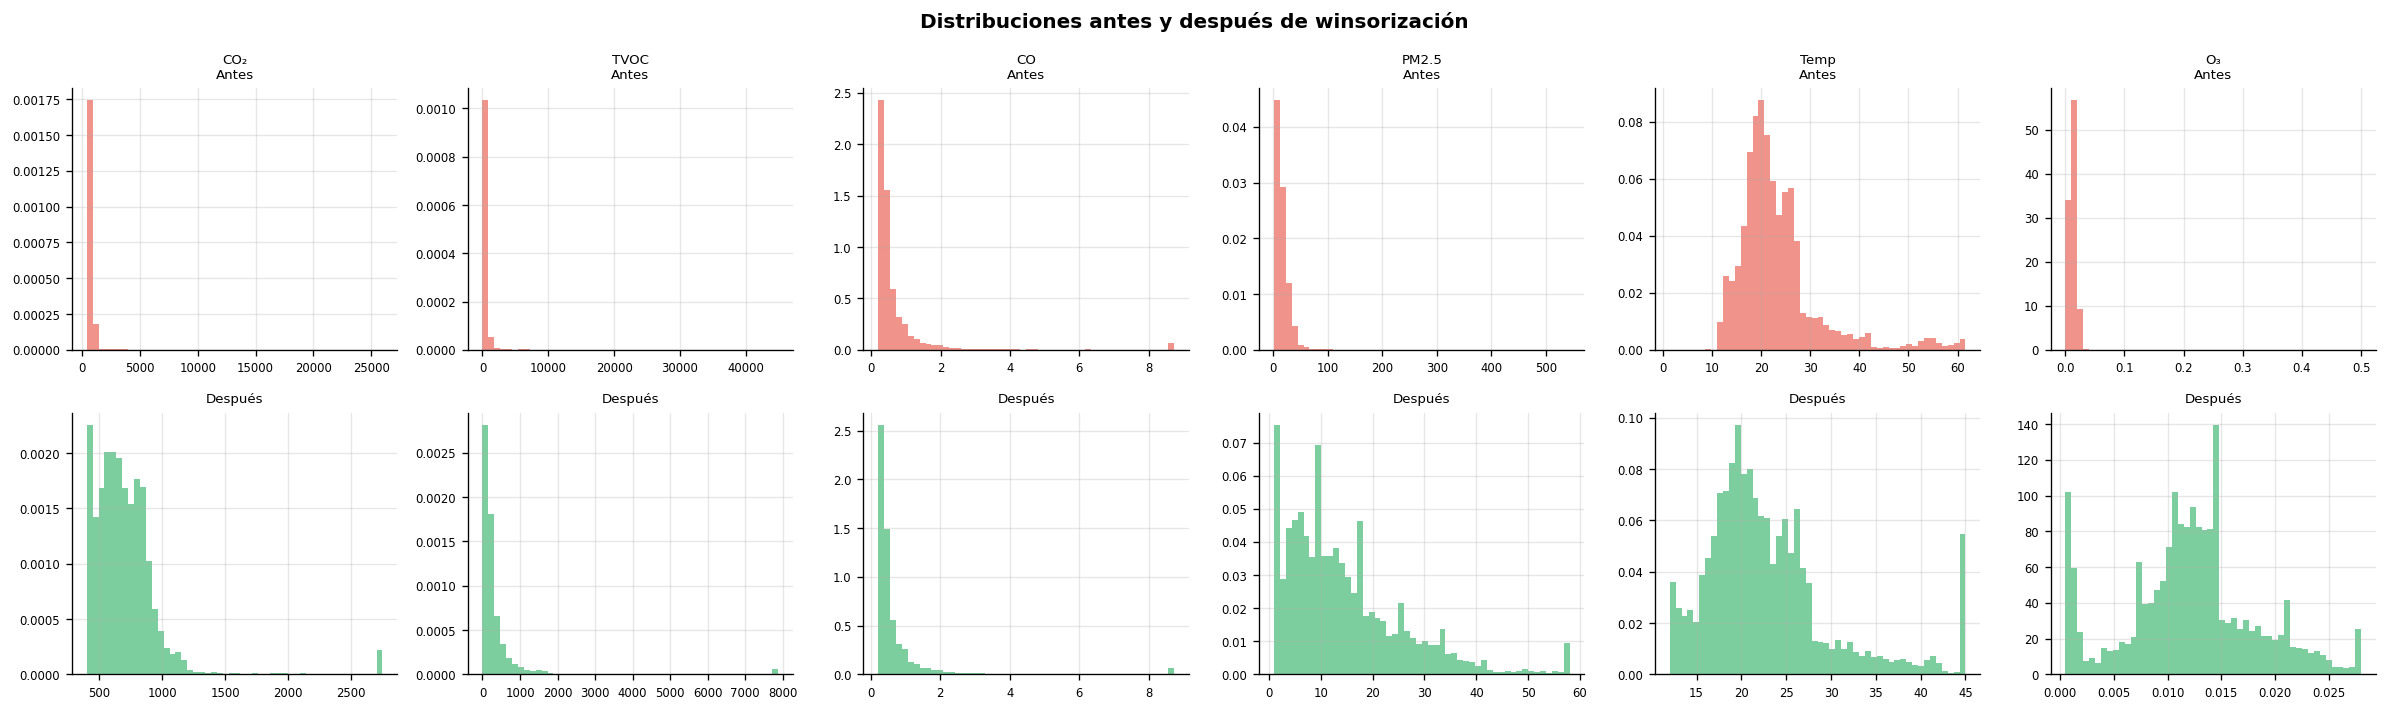

In [10]:
# verificación visual — antes (rojo) vs después (verde)
vars_check = ['CO2_ppm','TVOC_ppb','CO_ppm','PM2_5_ugm3','temp_C','O3_ppm']
labels_c   = ['CO₂','TVOC','CO','PM2.5','Temp','O₃']

fig, axes = plt.subplots(2, 6, figsize=(20, 6))
fig.suptitle('Distribuciones antes y después de winsorización', fontsize=12, fontweight='bold')

for i, (col, lbl) in enumerate(zip(vars_check, labels_c)):
    axes[0, i].hist(df[col],       bins=50, color='#e74c3c', alpha=0.6, density=True)
    axes[1, i].hist(df_clean[col], bins=50, color='#27ae60', alpha=0.6, density=True)
    axes[0, i].set_title(f'{lbl}\nAntes', fontsize=8)
    axes[1, i].set_title('Después', fontsize=8)
    for ax in [axes[0,i], axes[1,i]]:
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('Data/ETL_01_winsorisacion.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.5 Transformación logarítmica

Los contaminantes atmosféricos naturalmente siguen distribuciones log-normales. Su concentración es el resultado de procesos de dispersión y dilución que son multiplicativos, no aditivos, así que trabajar en escala logarítmica es más coherente físicamente.

Prácticamente: la transformación `log(1+x)` comprime las colas largas y hace que las distribuciones sean más simétricas, lo cual mejora el comportamiento de regresión logística, SVMs y regresión lineal. Para árboles de decisión no importa tanto, pero tampoco hace daño.

Aplicamos solo donde el sesgo es mayor a 1.5 (umbral estándar). Temperatura y humedad no la necesitan.

In [11]:
UMBRAL_SESGO = 1.5
vars_log = []

print(f"{'Variable':<18} {'Sesgo original':>15} {'Sesgo log1p':>13} {'Aplica':>8}")
print('-' * 58)

for col in VARS_AMB:
    sk = skew(df_clean[col])
    if sk > UMBRAL_SESGO:
        sk_log = skew(np.log1p(df_clean[col]))
        df_clean[f'{col}_log'] = np.log1p(df_clean[col])
        vars_log.append(col)
        print(f"{col:<18} {sk:>15.3f} {sk_log:>13.3f} {'  sí':>8}")
    else:
        print(f"{col:<18} {sk:>15.3f} {'—':>13} {'  no':>8}")

Variable            Sesgo original   Sesgo log1p   Aplica
----------------------------------------------------------
CO2_ppm                      3.996         1.037       sí
TVOC_ppb                     6.367        -0.910       sí
CO_ppm                       5.462         3.124       sí
SO2_ppm                      3.368         3.293       sí
O3_ppm                       0.138             —       no
NO2_ppm                      0.561             —       no
PM2_5_ugm3                   1.356             —       no
PM10_ugm3                    1.339             —       no
temp_C                       1.344             —       no
hum_pct                     -0.372             —       no


### 2.6 Features temporales

En el EDA vimos patrones diurnos claros: CO₂ y CO suben en las mañanas (~6–8h) coincidiendo con horas pico de tráfico. La temperatura tiene su ciclo normal de mínimo nocturno y máximo vespertino. Si no le damos al modelo información de la hora, pierde esa estructura.

El truco de `sin/cos` para la hora es necesario porque `hora=23` y `hora=0` son casi iguales en el tiempo real, pero con codificación lineal el modelo los vería como los más alejados posibles. Con la codificación cíclica eso se resuelve.

In [12]:
df_clean['hour']        = df_clean['datetime'].dt.hour
df_clean['day_of_week'] = df_clean['datetime'].dt.dayofweek
df_clean['is_weekend']  = (df_clean['day_of_week'] >= 5).astype(int)

# codificación cíclica
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)
df_clean['dow_sin']  = np.sin(2 * np.pi * df_clean['day_of_week'] / 7)
df_clean['dow_cos']  = np.cos(2 * np.pi * df_clean['day_of_week'] / 7)

print('Primeras 5 filas con features temporales:')
display(df_clean[['datetime','hour','day_of_week','is_weekend','hour_sin','hour_cos']].head())

Primeras 5 filas con features temporales:


,datetime,hour,day_of_week,is_weekend,hour_sin,hour_cos
0,2025-11-06 20:09:35,20,3,0,-0.866025,0.5
1,2025-11-06 20:10:18,20,3,0,-0.866025,0.5
2,2025-11-06 20:11:19,20,3,0,-0.866025,0.5
3,2025-11-06 20:12:19,20,3,0,-0.866025,0.5
4,2025-11-06 20:13:20,20,3,0,-0.866025,0.5


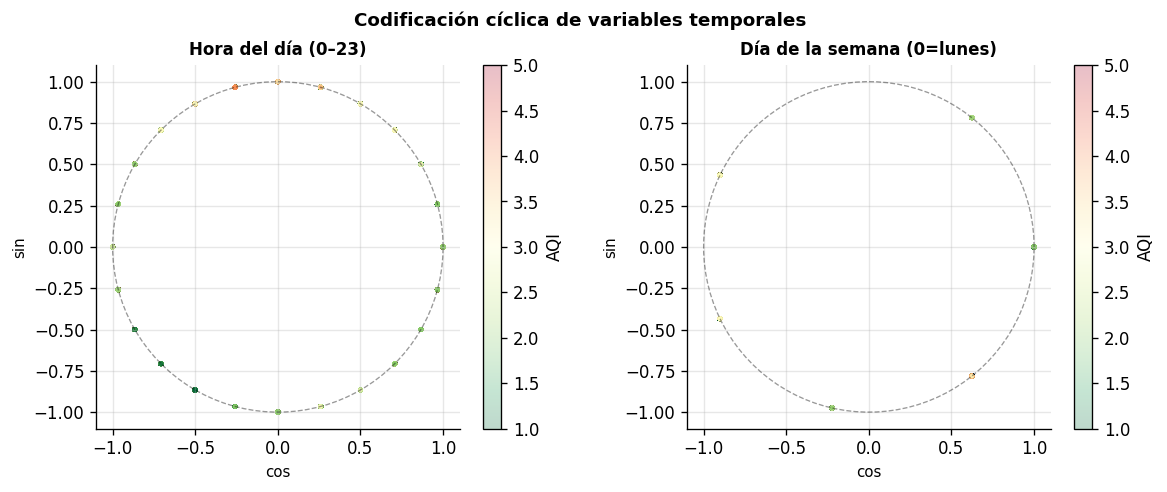

In [13]:
# ver la codificación cíclica en el espacio 2D
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
theta = np.linspace(0, 2*np.pi, 100)

pares = [('hour_cos','hour_sin','Hora del día (0–23)'),
         ('dow_cos', 'dow_sin', 'Día de la semana (0=lunes)')]

for ax, (cx, cy, titulo) in zip(axes, pares):
    sc = ax.scatter(df_clean[cx], df_clean[cy], c=df_clean['AQI'],
                    cmap='RdYlGn_r', alpha=0.25, s=4)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, alpha=0.4)
    ax.set_xlabel('cos', fontsize=9)
    ax.set_ylabel('sin', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, label='AQI')

plt.suptitle('Codificación cíclica de variables temporales', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('Data/ETL_02_ciclica.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.7 Features y targets finales

El AQI se puede usar de tres formas dependiendo del modelo:
- Como número continuo (1–5) para regresión
- Como clase entera (1/2/3/4/5) para clasificación multiclase
- Como binario (bueno/malo, umbral en 3) para clasificación binaria — útil si el desbalance entre clases extremas dificulta el multiclase

In [14]:
df_clean['AQI_clase']   = df_clean['AQI'].astype(int)
df_clean['AQI_binario'] = (df_clean['AQI'] >= 3).astype(int)

FEATURES_LOG  = [f'{c}_log' for c in vars_log]
FEATURES_ORIG = ['temp_C', 'hum_pct']
FEATURES_TEMP = ['hour_sin','hour_cos','dow_sin','dow_cos','is_weekend','periodo']
FEATURES      = FEATURES_LOG + FEATURES_ORIG + FEATURES_TEMP

print(f'Features de contaminantes (log-transformadas): {len(FEATURES_LOG)}')
print(f'Features meteorológicas:                       {len(FEATURES_ORIG)}')
print(f'Features temporales cíclicas:                  {len(FEATURES_TEMP)}')
print(f'Total features:                                {len(FEATURES)}')
print()
print('Distribución AQI_clase:')
print(df_clean['AQI_clase'].value_counts().sort_index())
print(f'\nAQI_binario: {df_clean["AQI_binario"].mean()*100:.1f}% son AQI >= 3')

Features de contaminantes (log-transformadas): 4
Features meteorológicas:                       2
Features temporales cíclicas:                  6
Total features:                                12

Distribución AQI_clase:
AQI_clase
1    2370
2    5964
3    3966
4    1171
5     287
Name: count, dtype: int64

AQI_binario: 39.4% son AQI >= 3


### 2.8 Estandarización

Aplicamos `StandardScaler` (media 0, std 1) a las variables continuas. Es necesario para modelos que usan distancias o gradientes (SVM, regresión logística, redes neuronales). Los árboles de decisión no lo necesitan, pero tampoco les afecta.

Las features cíclicas (sin/cos) ya están en [-1, 1], y las binarias en {0, 1}, así que no las escalamos.

Guardamos los parámetros del scaler en CSV para poder transformar datos nuevos en producción sin necesidad de re-ajustar.

In [15]:
FEATURES_A_ESCALAR = FEATURES_LOG + FEATURES_ORIG

scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[FEATURES_A_ESCALAR] = scaler.fit_transform(df_clean[FEATURES_A_ESCALAR])

print('Post-escalado (media ≈ 0, std ≈ 1):')
display(df_scaled[FEATURES_A_ESCALAR].describe().T[['mean','std','min','max']].round(4))

# guardar parámetros
pd.DataFrame({'feature': FEATURES_A_ESCALAR,
              'mean': scaler.mean_,
              'std':  scaler.scale_}).to_csv('Data/scaler_params.csv', index=False)
print('\nParámetros guardados en Data/scaler_params.csv')

Post-escalado (media ≈ 0, std ≈ 1):


,mean,std,min,max
CO2_ppm_log,-0.0,1.0,-1.6188,4.4655
TVOC_ppb_log,-0.0,1.0,-3.7876,2.8368
CO_ppm_log,0.0,1.0,-0.7831,5.3809
SO2_ppm_log,-0.0,1.0,-0.7394,5.5760
temp_C,-0.0,1.0,-1.5209,3.0791
hum_pct,0.0,1.0,-2.5263,1.8530



Parámetros guardados en Data/scaler_params.csv


### 2.9 Partición train / validation / test

Los datos son serie de tiempo, así que la división tiene que ser cronológica. Si la hiciéramos aleatoria, el modelo aprendería del futuro para predecir el pasado — las métricas saldrían muy buenas pero serían completamente irreales.

Proporción 70/15/15:
- **Train** — ajustar parámetros del modelo
- **Validation** — afinar hiperparámetros
- **Test** — evaluación final, no se toca hasta el modelo final

In [16]:
n       = len(df_scaled)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

df_train = df_scaled.iloc[:n_train].copy()
df_val   = df_scaled.iloc[n_train:n_train + n_val].copy()
df_test  = df_scaled.iloc[n_train + n_val:].copy()

for nombre, subdf in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    print(f'{nombre:<12} {len(subdf):>5,} registros '
          f'({100*len(subdf)/n:.0f}%)  '
          f'{subdf["datetime"].iloc[0].date()} → {subdf["datetime"].iloc[-1].date()}')

Train        9,630 registros (70%)  2025-11-06 → 2025-11-18
Validation   2,063 registros (15%)  2025-11-18 → 2025-11-23
Test         2,065 registros (15%)  2025-11-23 → 2025-11-25


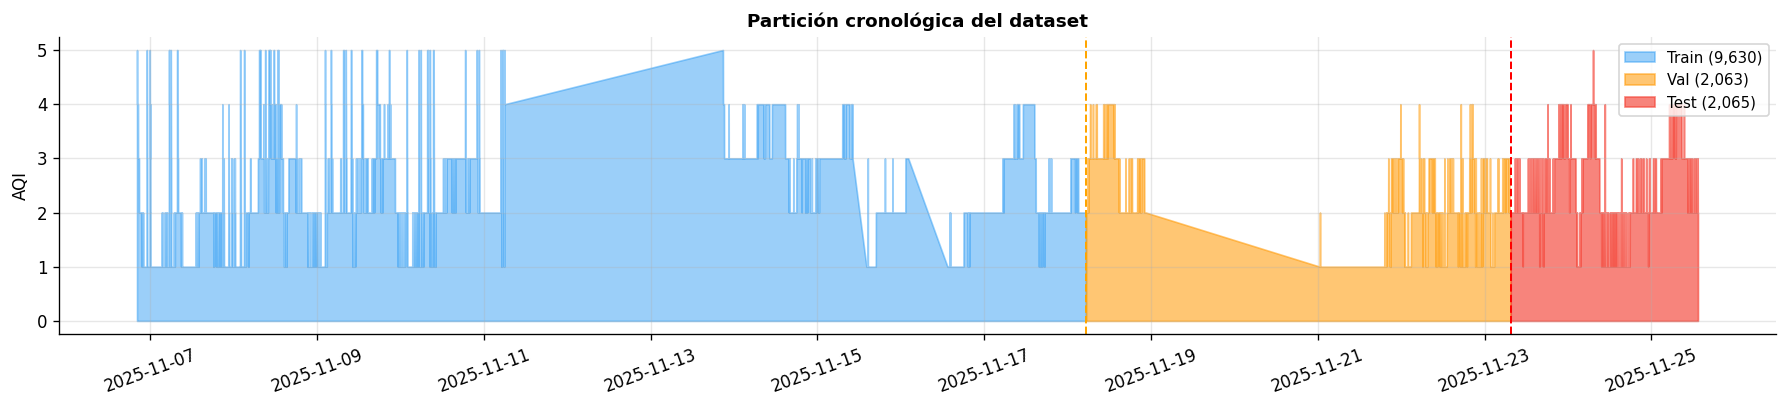

In [17]:
fig, ax = plt.subplots(figsize=(15, 3.5))

ax.fill_between(df_train['datetime'], df_train['AQI'], alpha=0.45, color='#2196F3', label=f'Train ({len(df_train):,})')
ax.fill_between(df_val['datetime'],   df_val['AQI'],   alpha=0.55, color='#FF9800', label=f'Val ({len(df_val):,})')
ax.fill_between(df_test['datetime'],  df_test['AQI'],  alpha=0.65, color='#F44336', label=f'Test ({len(df_test):,})')
ax.axvline(df_val['datetime'].iloc[0],  color='orange', linestyle='--', linewidth=1.2)
ax.axvline(df_test['datetime'].iloc[0], color='red',    linestyle='--', linewidth=1.2)
ax.set_title('Partición cronológica del dataset', fontsize=11, fontweight='bold')
ax.set_ylabel('AQI')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('Data/ETL_03_particion.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.10 Validación del dataset limpio

In [18]:
checks = []

# sin nulos
n_nulos = df_scaled[FEATURES + ['AQI','AQI_clase','AQI_binario']].isnull().sum().sum()
checks.append(('Sin valores nulos', n_nulos == 0, f'{n_nulos} nulos'))

# AQI en rango
aqi_ok = df_scaled['AQI_clase'].between(1, 5).all()
checks.append(('AQI_clase en [1,5]', aqi_ok, f'min={df_scaled["AQI_clase"].min()}, max={df_scaled["AQI_clase"].max()}'))

# orden temporal
sin_inversiones = (df_scaled['datetime'].diff().dropna() >= pd.Timedelta(0)).all()
checks.append(('Orden temporal preservado', sin_inversiones, ''))

# features escaladas con media ≈ 0
media_ok = (df_scaled[FEATURES_A_ESCALAR].mean().abs() < 0.01).all()
checks.append(('Media ≈ 0 en features escaladas', media_ok, ''))

for desc, ok, detalle in checks:
    estado = '✓' if ok else '✗'
    print(f'  {estado}  {desc}  {detalle}')

if all(ok for _, ok, _ in checks):
    print('\nDataset validado correctamente.')
else:
    print('\nHay problemas que resolver antes de exportar.')

  ✓  Sin valores nulos  0 nulos
  ✓  AQI_clase en [1,5]  min=1, max=5
  ✓  Orden temporal preservado  
  ✓  Media ≈ 0 en features escaladas  

Dataset validado correctamente.


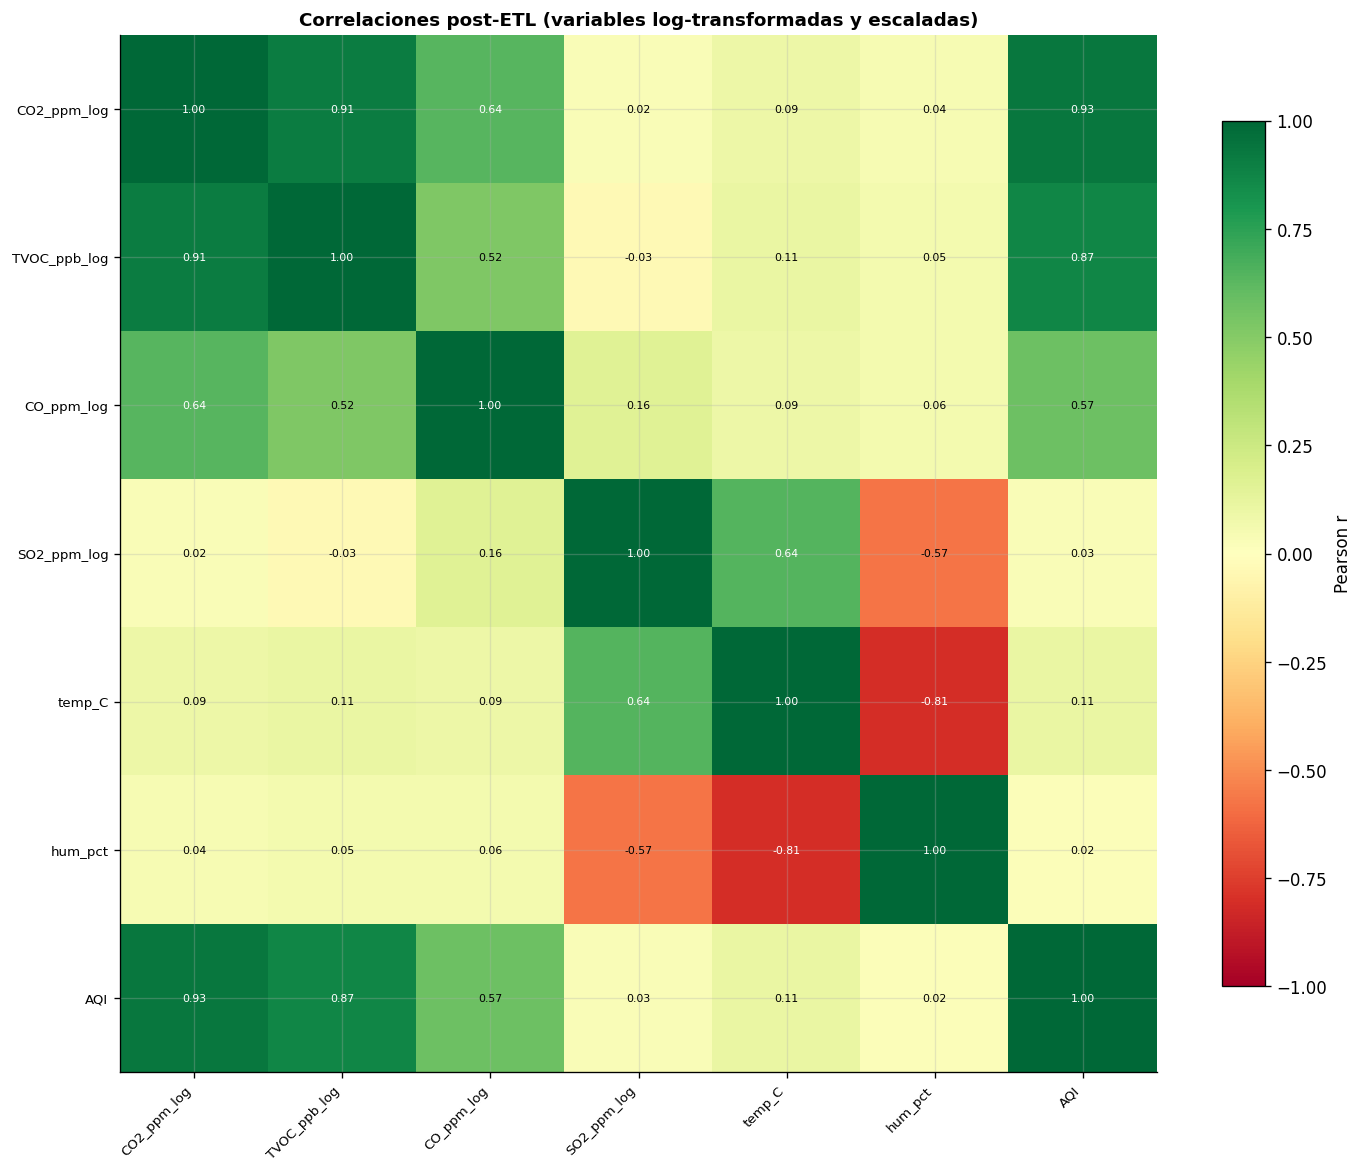

In [19]:
# correlaciones post-ETL
cols_corr = FEATURES_LOG + FEATURES_ORIG + ['AQI']
corr = df_scaled[cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
ax.set_xticks(range(len(cols_corr)))
ax.set_yticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols_corr, fontsize=8)
ax.set_title('Correlaciones post-ETL (variables log-transformadas y escaladas)', fontsize=11, fontweight='bold')

for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        v = corr.values[i, j]
        color = 'white' if abs(v) > 0.6 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5, color=color)

plt.tight_layout()
plt.savefig('Data/ETL_04_correlaciones_finales.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Carga — Exportar archivos

Se exportan seis archivos:
- Dataset completo listo para modelado
- Splits train/val/test por separado (más cómodo para el pipeline de ML)
- Parámetros del scaler para producción
- Diccionario de variables

In [20]:
COLS_FINAL = ['datetime','periodo','near_gap'] + FEATURES + ['AQI','AQI_clase','AQI_binario']
df_final   = df_scaled[COLS_FINAL].copy()

df_final.to_csv('Data/dataset_etl_completo.csv', index=False)
df_train[COLS_FINAL].to_csv('Data/dataset_train.csv', index=False)
df_val[COLS_FINAL].to_csv('Data/dataset_val.csv',   index=False)
df_test[COLS_FINAL].to_csv('Data/dataset_test.csv',  index=False)

print('Archivos exportados en Data/:')
print(f'  dataset_etl_completo.csv  — {len(df_final):,} filas × {len(COLS_FINAL)} columnas')
print(f'  dataset_train.csv         — {len(df_train):,} filas')
print(f'  dataset_val.csv           — {len(df_val):,} filas')
print(f'  dataset_test.csv          — {len(df_test):,} filas')
print(f'  scaler_params.csv         — medias y std para re-escalar en producción')

Archivos exportados en Data/:
  dataset_etl_completo.csv  — 13,758 filas × 18 columnas
  dataset_train.csv         — 9,630 filas
  dataset_val.csv           — 2,063 filas
  dataset_test.csv          — 2,065 filas
  scaler_params.csv         — medias y std para re-escalar en producción


In [21]:
# diccionario de variables
diccionario = pd.DataFrame([
    ('datetime',        'Temporal',     'Marca de tiempo original'),
    ('periodo',         'Categórica',   'Periodo de medición: 0=P1, 1=P2'),
    ('near_gap',        'Flag',         'Proximidad a brecha 19-20 Nov (±2h): 1=sí, 0=no'),
    ('CO2_ppm_log',     'Contaminante', 'log(1+CO₂ winsorizado) — estandarizada'),
    ('TVOC_ppb_log',    'Contaminante', 'log(1+TVOC winsorizado) — estandarizada'),
    ('CO_ppm_log',      'Contaminante', 'log(1+CO winsorizado) — estandarizada'),
    ('SO2_ppm_log',     'Contaminante', 'log(1+SO₂ winsorizado) — estandarizada'),
    ('O3_ppm_log',      'Contaminante', 'log(1+O₃ winsorizado) — estandarizada'),
    ('NO2_ppm_log',     'Contaminante', 'log(1+NO₂ winsorizado) — estandarizada'),
    ('PM2_5_ugm3_log',  'Contaminante', 'log(1+PM2.5 winsorizado) — estandarizada'),
    ('PM10_ugm3_log',   'Contaminante', 'log(1+PM10 winsorizado) — estandarizada'),
    ('temp_C',          'Meteorológica','Temperatura °C — estandarizada'),
    ('hum_pct',         'Meteorológica','Humedad relativa % — estandarizada'),
    ('hour_sin',        'Temporal',     'sin(2π·hora/24) — codificación cíclica'),
    ('hour_cos',        'Temporal',     'cos(2π·hora/24) — codificación cíclica'),
    ('dow_sin',         'Temporal',     'sin(2π·día/7) — codificación cíclica'),
    ('dow_cos',         'Temporal',     'cos(2π·día/7) — codificación cíclica'),
    ('is_weekend',      'Temporal',     '1=sábado o domingo, 0=día laborable'),
    ('AQI',             'Target',       'Índice de calidad del aire continuo (1.0–5.0)'),
    ('AQI_clase',       'Target',       'AQI como entero (1–5) para clasificación multiclase'),
    ('AQI_binario',     'Target',       '0=bueno (AQI<=2), 1=malo (AQI>=3)'),
], columns=['Variable','Tipo','Descripción'])

diccionario.to_csv('Data/diccionario_variables.csv', index=False)
display(diccionario)

,Variable,Tipo,Descripción
0,datetime,Temporal,Marca de tiempo original
1,periodo,Categórica,"Periodo de medición: 0=P1, 1=P2"
2,near_gap,Flag,"Proximidad a brecha 19-20 Nov (±2h): 1=sí, 0=no"
3,CO2_ppm_log,Contaminante,log(1+CO₂ winsorizado) — estandarizada
4,TVOC_ppb_log,Contaminante,log(1+TVOC winsorizado) — estandarizada
5,CO_ppm_log,Contaminante,log(1+CO winsorizado) — estandarizada
6,SO2_ppm_log,Contaminante,log(1+SO₂ winsorizado) — estandarizada
7,O3_ppm_log,Contaminante,log(1+O₃ winsorizado) — estandarizada
8,NO2_ppm_log,Contaminante,log(1+NO₂ winsorizado) — estandarizada
9,PM2_5_ugm3_log,Contaminante,log(1+PM2.5 winsorizado) — estandarizada


## Resumen del proceso ETL

In [22]:
print('RESUMEN ETL — CALIDAD DEL AIRE (SENSOR D)')
print('=' * 55)
print(f'Registros originales (Sensor D):  {len(df):,}')
print(f'Registros finales:                {len(df_final):,}  (se conservan todos)')
print()
print('Transformaciones:')
print(f'  - Eliminadas:        Bat_pct, sensor_periodo (texto)')
print(f'  - Winsorización:     {len(VARS_AMB)} variables (p1–p99, temp máx 45°C)')
print(f'  - log1p aplicada:    {len(vars_log)} contaminantes (sesgo > 1.5)')
print(f'  - Estandarización:   {len(FEATURES_A_ESCALAR)} features continuas')
print(f'  - Features creadas:  hora/día cíclicos, is_weekend, periodo, near_gap')
print(f'  - Features totales:  {len(FEATURES)}')
print()
print('Partición cronológica 70/15/15:')
print(f'  Train:  {len(df_train):,} ({100*len(df_train)/n:.0f}%)  {df_train["datetime"].iloc[0].date()} → {df_train["datetime"].iloc[-1].date()}')
print(f'  Val:    {len(df_val):,} ({100*len(df_val)/n:.0f}%)  {df_val["datetime"].iloc[0].date()} → {df_val["datetime"].iloc[-1].date()}')
print(f'  Test:   {len(df_test):,} ({100*len(df_test)/n:.0f}%)  {df_test["datetime"].iloc[0].date()} → {df_test["datetime"].iloc[-1].date()}')

RESUMEN ETL — CALIDAD DEL AIRE (SENSOR D)
Registros originales (Sensor D):  13,758
Registros finales:                13,758  (se conservan todos)

Transformaciones:
  - Eliminadas:        Bat_pct, sensor_periodo (texto)
  - Winsorización:     10 variables (p1–p99, temp máx 45°C)
  - log1p aplicada:    4 contaminantes (sesgo > 1.5)
  - Estandarización:   6 features continuas
  - Features creadas:  hora/día cíclicos, is_weekend, periodo, near_gap
  - Features totales:  12

Partición cronológica 70/15/15:
  Train:  9,630 (70%)  2025-11-06 → 2025-11-18
  Val:    2,063 (15%)  2025-11-18 → 2025-11-23
  Test:   2,065 (15%)  2025-11-23 → 2025-11-25
